# Interventions: Policy Language to Model Controls

This notebook is an illustrative bridge between policy concepts and model parameters.

Map/Territory note:
- Territory: ventilation, masking, tracing, isolation, and behavior changes in real settings
- Map: within-group and bridge transmission scalars in a contact matrix

The purpose is pedagogical: make assumptions explicit and test consequences.

## Policy-to-Model Translation (Working Draft)

| Policy framing | Model control |
| --- | --- |
| Improve ventilation/masking in cluster settings | scale cluster diagonal entry (within-group) |
| Contact tracing + isolation of bridge cases | scale specific bridge entries between groups |
| Broad social distancing | scale many off-diagonal entries and possibly all diagonals |
| Targeted vaccination in one group | (future) change susceptible stock or effective transmission in that group |

In [1]:
from pathlib import Path
import sys
import importlib

project_root = Path.cwd()
if not (project_root / "src").exists():
    project_root = project_root.parent
sys.path.insert(0, str(project_root / "src"))

ENABLE_RELOAD = False

import epi_structure.parameters as parameters_module
import epi_structure.model as model_module
import epi_structure.contact_matrix as contact_matrix_module
import epi_structure.interventions as interventions_module

if ENABLE_RELOAD:
    parameters_module = importlib.reload(parameters_module)
    model_module = importlib.reload(model_module)
    contact_matrix_module = importlib.reload(contact_matrix_module)
    interventions_module = importlib.reload(interventions_module)

DiseaseParameters = parameters_module.DiseaseParameters
PopulationParameters = parameters_module.PopulationParameters
SimulationParameters = parameters_module.SimulationParameters
StructuredEpidemicModel = model_module.StructuredEpidemicModel
preset_general_cluster = contact_matrix_module.preset_general_cluster
ContactMatrixIntervention = interventions_module.ContactMatrixIntervention
InterventionPlan = interventions_module.InterventionPlan
intervene_within_groups = interventions_module.intervene_within_groups
intervene_bridge_links = interventions_module.intervene_bridge_links
compose_intervention_plan = interventions_module.compose_intervention_plan

import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.patches import Circle, FancyArrowPatch

In [2]:
names, contact_matrix = preset_general_cluster()

shared_disease = DiseaseParameters(infectious_period=6.0, latent_period=2.5)
populations = [
    PopulationParameters(name="general", size=10_000, beta=0.0, initial_infected=1, disease=shared_disease),
    PopulationParameters(name="cluster", size=500, beta=0.0, initial_infected=4, disease=shared_disease),
]
simulation = SimulationParameters(time_step=0.1, duration=60.0, output_stride=10)

display(pd.DataFrame(contact_matrix, index=names, columns=names))

,general,cluster
general,0.00004,0.00018
cluster,0.00001,0.00050


In [3]:
def policy_plan(policy_name: str) -> InterventionPlan | None:
    start_time = 20.0

    if policy_name == "baseline":
        return None

    if policy_name == "cluster_ventilation":
        return compose_intervention_plan(
            intervene_within_groups(["cluster"], 0.4, start_time=start_time)
        )

    if policy_name == "bridge_tracing":
        return compose_intervention_plan(
            intervene_bridge_links(
                [("general", "cluster")],
                0.2,
                start_time=start_time,
                symmetric=True,
            )
        )

    if policy_name == "targeted_combo":
        return compose_intervention_plan(
            intervene_within_groups(["cluster"], 0.4, start_time=start_time),
            intervene_bridge_links(
                [("general", "cluster")],
                0.2,
                start_time=start_time,
                symmetric=True,
            ),
        )

    raise ValueError(f"Unknown policy: {policy_name}")


def run_policy(policy_name: str):
    model = StructuredEpidemicModel(
        populations=populations,
        contact_matrix=contact_matrix,
        simulation=simulation,
        intervention_plan=policy_plan(policy_name),
    )
    return model.simulate()


def effective_matrix(policy_name: str, time: float) -> list[list[float]]:
    plan = policy_plan(policy_name)
    if plan is None:
        return [row[:] for row in contact_matrix]
    return plan.matrix_at_time(contact_matrix, names, time)


def intervention_targets(plan: InterventionPlan | None):
    groups = set()
    links = set()

    if plan is None:
        return groups, links

    for intervention in plan.interventions:
        if isinstance(intervention.within_scale, dict):
            groups.update(intervention.within_scale.keys())
        elif isinstance(intervention.within_scale, (int, float)):
            groups.update(names)

        if isinstance(intervention.bridge_scale, dict):
            links.update(intervention.bridge_scale.keys())
        elif isinstance(intervention.bridge_scale, (int, float)):
            for to_name in names:
                for from_name in names:
                    if to_name != from_name:
                        links.add((to_name, from_name))

    return groups, links

## Visual Map: Groups and Bridge Links

This view makes the transformation explicit:
- choose a policy (selector)
- identify the targeted groups/links (subset)
- compare base vs effective matrix at a chosen time (transform result)

,general,cluster
general,0.00004,0.00018
cluster,0.00001,0.00050


,general,cluster
general,0.000040,0.000036
cluster,0.000002,0.000200


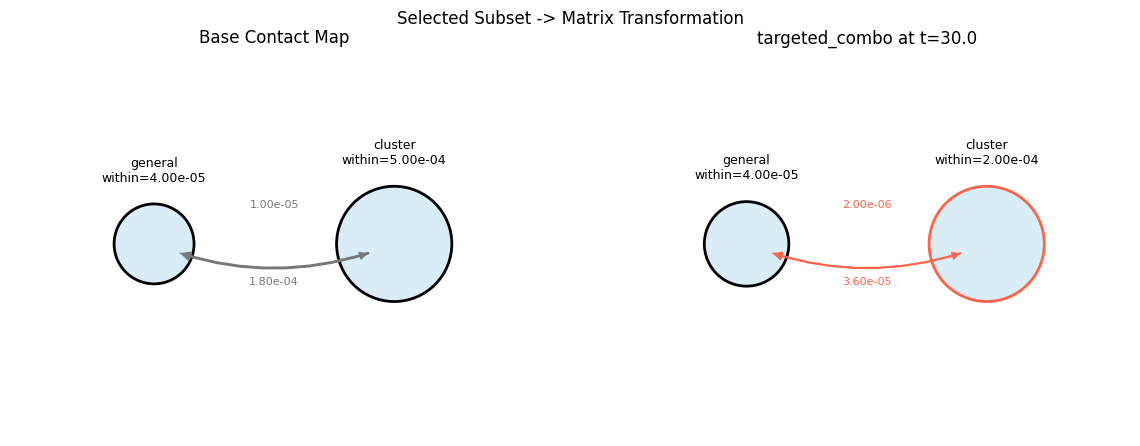

In [9]:
def fmt_weight(value: float) -> str:
    abs_value = abs(value)
    if abs_value == 0:
        return "0"
    if abs_value < 0.01:
        return f"{value:.2e}"
    return f"{value:.3f}"


def draw_group_bridge_map(
    ax,
    names,
    matrix,
    title,
    highlighted_groups=None,
    highlighted_links=None,
):
    highlighted_groups = highlighted_groups or set()
    highlighted_links = highlighted_links or set()
    index = {name: i for i, name in enumerate(names)}
    positions = {
        name: (float(i), 0.0)
        for i, name in enumerate(names)
    }

    max_entry = max(max(row) for row in matrix) if matrix else 1.0
    max_entry = max(max_entry, 1e-9)

    for name, (x, y) in positions.items():
        i = index[name]
        diag = matrix[i][i]
        radius = 0.16 + 0.08 * (diag / max_entry)
        edgecolor = "tomato" if name in highlighted_groups else "black"
        circle = Circle((x, y), radius=radius, facecolor="#d9edf7", edgecolor=edgecolor, linewidth=2)
        ax.add_patch(circle)
        ax.text(
            x,
            y + radius + 0.08,
            f"{name}\nwithin={fmt_weight(diag)}",
            ha="center",
            va="bottom",
            fontsize=9,
        )

    n = len(names)
    for to_idx in range(n):
        for from_idx in range(n):
            if to_idx == from_idx:
                continue

            to_name = names[to_idx]
            from_name = names[from_idx]
            value = matrix[to_idx][from_idx]
            start = positions[from_name]
            end = positions[to_name]

            if start == end:
                continue

            is_highlighted = (to_name, from_name) in highlighted_links
            color = "tomato" if is_highlighted else "#777777"
            linewidth = 1.0 + 3.0 * (value / max_entry)

            arrow = FancyArrowPatch(
                start,
                end,
                arrowstyle="-|>",
                mutation_scale=12,
                color=color,
                linewidth=linewidth,
                connectionstyle="arc3,rad=0.2" if from_idx < to_idx else "arc3,rad=-0.2",
                shrinkA=20,
                shrinkB=20,
            )
            ax.add_patch(arrow)

            mid_x = (start[0] + end[0]) / 2
            mid_y = (start[1] + end[1]) / 2
            offset = 0.16 if from_idx < to_idx else -0.16
            ax.text(
                mid_x,
                mid_y + offset,
                fmt_weight(value),
                ha="center",
                va="center",
                fontsize=8,
                color=color,
            )

    ax.set_title(title)
    ax.set_xlim(-0.6, len(names) - 0.4)
    ax.set_ylim(-0.8, 0.8)
    ax.set_aspect("equal")
    ax.axis("off")


policy_to_view = "targeted_combo"
time_to_view = 30.0

plan = policy_plan(policy_to_view)
groups, links = intervention_targets(plan)
base_matrix = [row[:] for row in contact_matrix]
effective = effective_matrix(policy_to_view, time_to_view)

display(pd.DataFrame(base_matrix, index=names, columns=names).round(6))
display(pd.DataFrame(effective, index=names, columns=names).round(6))

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
draw_group_bridge_map(
    axes[0],
    names,
    base_matrix,
    "Base Contact Map",
)
draw_group_bridge_map(
    axes[1],
    names,
    effective,
    f"{policy_to_view} at t={time_to_view}",
    highlighted_groups=groups,
    highlighted_links=links,
)

fig.suptitle("Selected Subset -> Matrix Transformation")
plt.tight_layout()
plt.show()

In [5]:
scenario_names = [
    "baseline",
    "cluster_ventilation",
    "bridge_tracing",
    "targeted_combo",
]
runs = {name: run_policy(name) for name in scenario_names}

len(runs), {k: len(v) for k, v in runs.items()}

(4,
 {'baseline': 61,
  'cluster_ventilation': 61,
  'bridge_tracing': 61,
  'targeted_combo': 61})

In [6]:
def summarize_run(name, trajectory):
    general = [pt.by_population["general"].infected for pt in trajectory]
    cluster = [pt.by_population["cluster"].infected for pt in trajectory]
    times = [pt.time for pt in trajectory]

    general_pct = [100.0 * x / 10_000 for x in general]
    cluster_pct = [100.0 * x / 500 for x in cluster]

    g_peak_idx = max(range(len(general)), key=lambda i: general[i])
    c_peak_idx = max(range(len(cluster)), key=lambda i: cluster[i])

    return {
        "scenario": name,
        "general_peak_I": general[g_peak_idx],
        "general_peak_t": times[g_peak_idx],
        "general_end_I": general[-1],
        "general_peak_pct": general_pct[g_peak_idx],
        "cluster_peak_I": cluster[c_peak_idx],
        "cluster_peak_t": times[c_peak_idx],
        "cluster_end_I": cluster[-1],
        "cluster_peak_pct": cluster_pct[c_peak_idx],
    }


summary = pd.DataFrame([summarize_run(name, runs[name]) for name in scenario_names])
summary.round(3)

,scenario,general_peak_I,general_peak_t,general_end_I,general_peak_pct,cluster_peak_I,cluster_peak_t,cluster_end_I,cluster_peak_pct
0,baseline,1896.851,40.0,524.685,18.969,74.068,43.0,34.848,14.814
1,cluster_ventilation,1807.044,40.0,553.086,18.070,47.526,45.0,28.935,9.505
2,bridge_tracing,1637.209,41.0,613.132,16.372,41.613,49.0,34.325,8.323
3,targeted_combo,1616.085,41.0,613.573,16.161,14.496,22.0,11.251,2.899


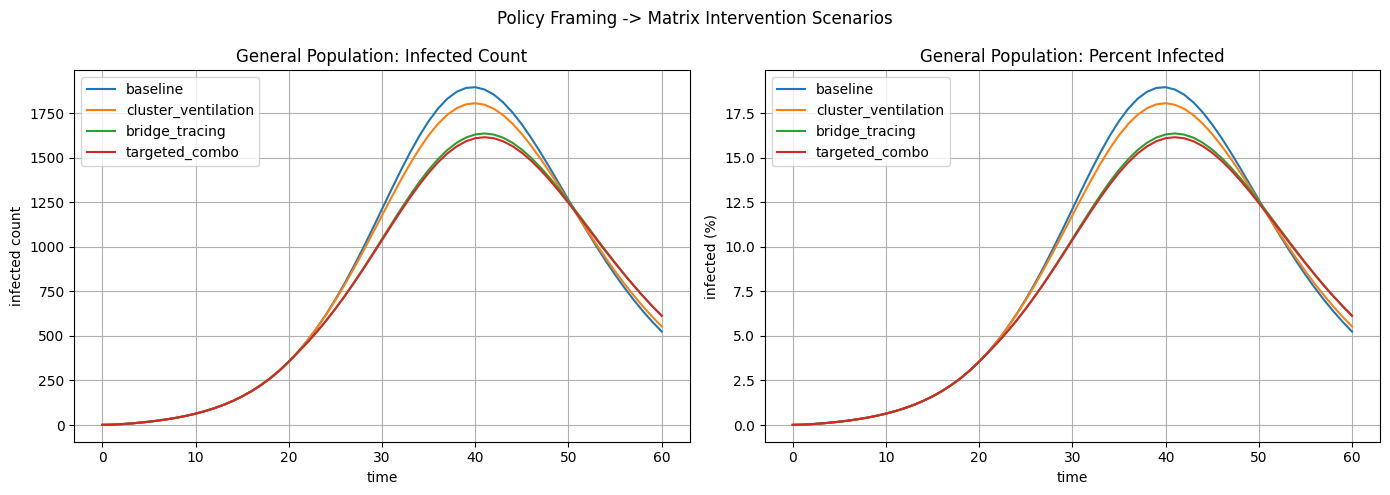

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharex=True)

for name, trajectory in runs.items():
    times = [pt.time for pt in trajectory]
    general = [pt.by_population["general"].infected for pt in trajectory]
    general_pct = [100.0 * x / 10_000 for x in general]

    axes[0].plot(times, general, label=name)
    axes[1].plot(times, general_pct, label=name)

axes[0].set_title("General Population: Infected Count")
axes[0].set_xlabel("time")
axes[0].set_ylabel("infected count")
axes[0].grid(True)
axes[0].legend()

axes[1].set_title("General Population: Percent Infected")
axes[1].set_xlabel("time")
axes[1].set_ylabel("infected (%)")
axes[1].grid(True)
axes[1].legend()

fig.suptitle("Policy Framing -> Matrix Intervention Scenarios")
plt.tight_layout()
plt.show()

In [8]:
assert all(len(traj) > 0 for traj in runs.values())
assert set(summary["scenario"]) == set(scenario_names)
assert summary["general_peak_I"].notna().all()
print("Intervention scenario checks passed.")

Intervention scenario checks passed.
